# Uncertainties on the number of backgrounds events

## Objectives

 * **Estimate the uncertainties in the number of background events**

## Physics

We estimate the parameter uncertainties using the log-likelihood scan.

We have estimated the parameters as the values where the $-2\log$ likelihood has a minimum.

We estimate the uncertainties at the 68% confidence level using the values where the $-2\log$ likelihood increases by one unit with respect to the minimum:

$$
\Delta - 2 \log \mathcal{L}( {\bf E} | {\bf n}) = 1
$$

where ${\bf n} = \{n^{Bi}_b, n^{Tl}_b\}$ are the number of background events for Bi and Tl respectively.

To be precise, to compute the uncertainty on $n^{Bi}_b$ we scan the likelihood along $n^{Bi}_b$, but we estimate the other parameter $\hat{n}^{Tl}_b(n^{Bi}_b)$ as the value that minimises the $-2\log$ likelihood for a fixed $n^{Bi}_b$.

## Analysis

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

#### Importing modules

In [2]:
import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats     as stats  # statistics and many PDFs 
#import scipy.optimize  as optimize # Minimize functions

import warnings
warnings.filterwarnings('ignore')

In [3]:
import os, sys
from pathlib import Path

# Find the project root: honours FANAL_ROOT env-var, otherwise walks up from cwd
_env = os.environ.get('FANAL_ROOT') or os.environ.get('USCFANALDIR')
if _env and Path(_env, 'data').is_dir():
    rootpath = str(Path(_env).resolve())
else:
    rootpath = str(next(p for p in [Path.cwd(), *Path.cwd().parents]
                        if (p / 'data').is_dir() and (p / 'ana').is_dir()))
if rootpath not in sys.path:
    sys.path.insert(0, rootpath)
print('Fanal root : ', rootpath)

Fanal root :  /home/daniel/GitHub/Grupo_beta_DM


In [4]:
import core.pltext  as pltext   # extensions for plotting histograms
import core.hfit    as hfit     # extension to fit histograms
import core.efit    as efit     # Fit Utilites - Includes Extend Likelihood Fit with composite PDFs
import core.utils   as ut       # generic utilities
import ana.fanal    as fn       # analysis functions specific to fanal
import ana.pltfanal as pltfn    # plotting fanal functions
import     collpars as collpars # collaboration specific parameters
pltext.style()

### Parameters

In [5]:
collaboration = collpars.collaboration
sel_erange    = collpars.sel_erange
sel_eroi      = collpars.sel_eroi

eff_Bi_blind  = collpars.eff_Bi_blind
eff_Tl_blind  = collpars.eff_Tl_blind

eff_Bi_E      = collpars.eff_Bi_E
eff_Tl_E      = collpars.eff_Tl_E
eff_Bi_RoI    = collpars.eff_Bi_RoI
eff_Tl_RoI    = collpars.eff_Tl_RoI

print('Collaboration         : {:s}'.format(collaboration))
print('Energy range          : ({:6.3f}, {:6.3f}) MeV'.format(*sel_erange))
print('RoI    range          : ({:6.3f}, {:6.3f}) MeV'.format(*sel_eroi))
print('Bi eff in E range     : {:6.4f} %'.format(100.*eff_Bi_E))
print('Tl eff in E range     : {:6.4f} %'.format(100.*eff_Tl_E))
print('Bi eff in RoI         : {:6.4f} %'.format(100.*eff_Bi_RoI))
print('Tl eff in RoI         : {:6.4f} %'.format(100.*eff_Tl_RoI))

Collaboration         : new_beta
Energy range          : ( 2.440,  2.470) MeV
RoI    range          : ( 2.445,  2.470) MeV
Bi eff in E range     : 7.3200 %
Tl eff in E range     : 0.1290 %
Bi eff in RoI         : 5.6000 %
Tl eff in RoI         : 0.1080 %


In [6]:
# number of  blind events
n_Bi_blind = eff_Bi_blind * collpars.n_Bi_total
n_Tl_blind = eff_Tl_blind * collpars.n_Tl_total
n_blind    = [n_Bi_blind, n_Tl_blind]
print('Number of bkg events in blind data : Bi = {:6.2f}, Tl = {:6.2f}.'.format(*n_blind))

Number of bkg events in blind data : Bi = 828.42, Tl = 1081.56.


## Access the data

In [7]:
filename = '/data/fanal_' + collaboration + '.h5'
print('Data path and filename : ', rootpath + filename)

mcbi       = pd.read_hdf(rootpath + filename, key = 'mc/bi214').fillna(0.)   # MC Bi
mctl       = pd.read_hdf(rootpath + filename, key = 'mc/tl208').fillna(0.)   # MC Tl
data_blind = pd.read_hdf(rootpath + filename, key = 'data/blind').fillna(0.) # blind data

mc_samples         = [mcbi, mctl]
sample_names       = ['Bi', 'Tl']
sample_names_latex = [r'$^{214}$Bi', r'$^{208}$Tl']

Data path and filename :  /home/daniel/GitHub/Grupo_beta_DM/data/fanal_new_beta.h5


### Re-do the fit to the blind data

Initial   number of events : 828.42,  1081.56, 
Estimated number of events : 828.89,  1082.22, 


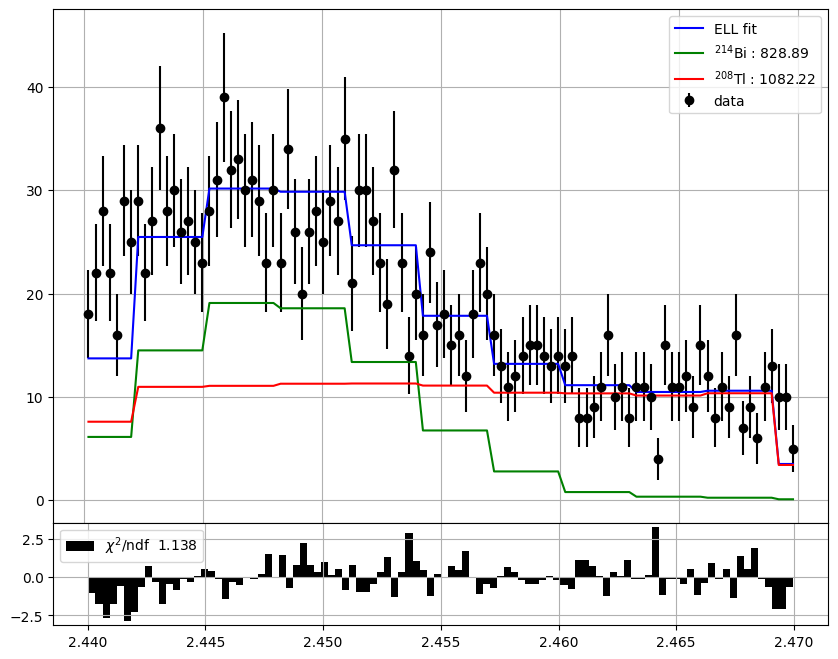

In [8]:
# get the blind mc samples
mcs_blind  = [mc[fn.selection_blind(mc)] for mc in mc_samples]

varname   = 'E'
refnames  = (varname,) 
refranges = (sel_erange,)

fit        = fn.prepare_fit_ell(mcs_blind, n_blind, refnames, refranges)

result, enes, ell, _ = fit(data_blind)
n_est = result.x

print('Initial   number of events :', *['{:6.2f}, '.format(ni) for ni in n_blind])
print('Estimated number of events :', *['{:6.2f}, '.format(ni) for ni in n_est])
# it also plots the histogram, the fit function, and the pdfs samples
pltfn.plot_fit_ell(enes, n_est, ell, parnames = sample_names_latex)

### Profile Likelihood Scan

We compute the uncertainties using the log-likelihood scan.

The uncertainties on $\mu$, in the Gaussian approximation, when there are two parameters $\mu, \nu$, are defined as the $\mu$ values where:

$$
t_\mu(x) \equiv \Delta - 2 \mathrm{log} \mathcal{L}(x | \mu, \nu) = 
-2 \, \mathrm{log} \frac{\mathcal{L}(x | \mu, \hat{\nu}(\mu))}{\mathcal{L}(x | \hat{\mu}, \hat{\nu})}  = 1
$$


In the plot, the confidence intervals at 68% CL of a parameter correspond to the segment defined by the points where the $\Delta -2 \log \mathcal{L} = 1$ line crosses the likelihood parabola.

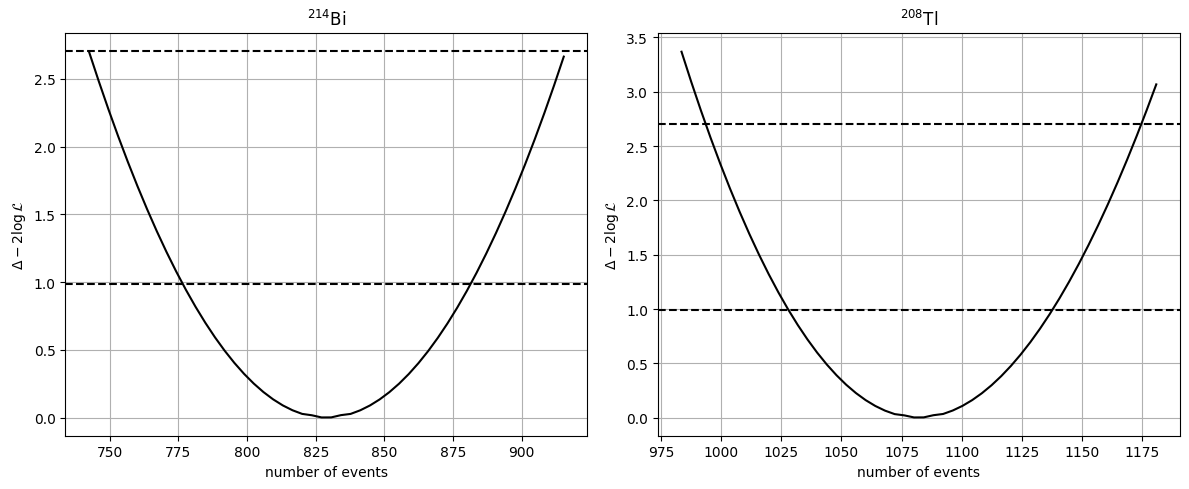

In [9]:
nis, tmus = fn.tmu_scan(enes, n_est, ell, sizes = (3., 3.))
pltfn.plot_tmu_scan(nis, tmus, titles = sample_names_latex)

In [10]:
cl    = 0.68
mucis = [efit.tmu_conf_int(ni, tmu, cl) for ni, tmu in zip(nis, tmus)]
for i, ci in enumerate(mucis):
    print('Number of {:s} events CI at {:4.0f} % CL = ({:5.2f}, {:5.2f})'.format(sample_names[i], 100*cl, *ci))

Number of Bi events CI at   68 % CL = (777.78, 880.01)
Number of Tl events CI at   68 % CL = (1031.87, 1136.60)


In [11]:
for i, ci in enumerate(mucis):
    print('Number of {:s} events CI at {:4.0f} % CL = {:5.2f}  {:5.2f} +{:5.2f}'.format(sample_names[i], 100*cl, 
                                                                                        result.x[i],
                                                                                        *(ci - result.x[i])))
    print(ci - result.x[i])

Number of Bi events CI at   68 % CL = 828.89  -51.12 +51.12
[-51.11783699  51.11783699]
Number of Tl events CI at   68 % CL = 1082.22  -50.35 +54.38
[-50.35276605  54.38098734]


### Computing the uncertainties in the number of Bkg

 Now the uncertainties in the number of background events in the RoI are:

 $$
\sigma_{n^k_{RoI}} = \frac{\epsilon^k_{RoI}}{\epsilon^k_b}\sigma_{n^k_{b}}, \;\; k = \mathrm{Bi}, \mathrm{Tl}
 $$


In [12]:
# Compute the uncertainties on the number of background events in the RoI.
#
# From the profile likelihood scan, extract the uncertainty on n_blind:
#   un_blind = [(ci[1] - ci[0]) / 2 for ci in mucis]
#
# Then propagate to the RoI using:
#   sigma_n_k_RoI = (eff_k_RoI / eff_k_blind) * sigma_n_k_blind
# YOUR CODE HERE

ci = mucis[0]
sigma_n_Tl_blind = (ci[1] - ci[0]) / 2
sigma_n_Tl_RoI = (eff_Tl_RoI / eff_Tl_blind) * sigma_n_Tl_blind


ci = mucis[1]
sigma_n_Bi_blind = (ci[1] - ci[0]) / 2
un_blind = [(ci[1] - ci[0]) / 2 for ci in mucis]

sigma_n_Bi_RoI = (eff_Tl_RoI / eff_Tl_blind) * sigma_n_Bi_blind

### Notation-to-code reference

| Math | Python variable | Description |
|------|-----------------|-------------|
| $\sigma_{n^\mathrm{Bi}_b}$ | `un_Bi_blind` | Uncertainty on $^{214}$Bi blind event count |
| $\sigma_{n^\mathrm{Tl}_b}$ | `un_Tl_blind` | Uncertainty on $^{208}$Tl blind event count |

In [13]:
import ana.fanal_display as fdisp

# Check your values before writing to collpars.py
fdisp.display_collpars([
    (r'\sigma_{n^\mathrm{' + sample + r'}_b}', 'un_' + sample + '_blind', un_blind[i], '.3f')
    for i, sample in enumerate(sample_names)
])

Math,Python variable,Your value
$\sigma_{n^\mathrm{Bi}_b}$,un_Bi_blind,51.118
$\sigma_{n^\mathrm{Tl}_b}$,un_Tl_blind,52.367


## Write Out

**Exercise**: Compute the uncertainties on the total, blind, energy-range, and RoI efficiencies, and store those values in the *collaboration* parameter file.

In [14]:
un_total = np.zeros(2)
un_E = np.zeros(2)
un_RoI = np.zeros(2)
un_total[0] = un_blind[0]/ eff_Bi_blind
un_total[1] = un_blind[1]/ eff_Tl_blind
un_E[0] = un_total[0] * eff_Bi_E
un_E[1] = un_total[1] * eff_Tl_E
un_RoI[0] = un_total[0] * eff_Bi_RoI
un_RoI[1] = un_total[1] * eff_Tl_RoI

fdisp.display_collpars([(r'\sigma_{n^\mathrm{' + sample + r'}_b}', 'un_' + sample + '_total', un_total[i], '.3f') for i, sample in enumerate(sample_names)])
fdisp.display_collpars([(r'\sigma_{n^\mathrm{' + sample + r'}_b}', 'un_' + sample + '_E', un_E[i], '.3f') for i, sample in enumerate(sample_names)])
fdisp.display_collpars([(r'\sigma_{n^\mathrm{' + sample + r'}_b}', 'un_' + sample + '_RoI', un_RoI[i], '.3f') for i, sample in enumerate(sample_names)])




Math,Python variable,Your value
$\sigma_{n^\mathrm{Bi}_b}$,un_Bi_total,65.118
$\sigma_{n^\mathrm{Tl}_b}$,un_Tl_total,74.069


Math,Python variable,Your value
$\sigma_{n^\mathrm{Bi}_b}$,un_Bi_E,4.767
$\sigma_{n^\mathrm{Tl}_b}$,un_Tl_E,0.096


Math,Python variable,Your value
$\sigma_{n^\mathrm{Bi}_b}$,un_Bi_RoI,3.647
$\sigma_{n^\mathrm{Tl}_b}$,un_Tl_RoI,0.080


In [15]:
write = True

collpar_filename = "collpars.py"
if (write):
    of = open(collpar_filename, 'a')
    for i, sample in enumerate(sample_names):
        of.write('un_'+sample+'_blind     = {:6.3f}'.format(un_blind[i])+'\n')
        of.write('un_'+sample+'           = {:6.3f}'.format(un_total[i])+'\n')
        of.write('un_'+sample+'_E         = {:6.3f}'.format(un_E[i])  +'\n')
        of.write('un_'+sample+'_RoI       = {:6.3f}'.format(un_RoI[i])  +'\n')
    of.close()